In [1]:
# # Formatting notebook to fit the browser size
# # # commented out so not to produce error
# from IPython.core.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))

In [3]:
#Make a new folder for the output pdfs
PATH = 'output/PDFs'
if not os.path.exists(PATH):
    os.makedirs(PATH)

In [6]:
# Loading libraries and packages

import os

import os
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
import scipy.optimize
import scipy.stats
import scipy.integrate as integrate
import scipy.integrate as special
import pandas as pd
import linecache
from statistics import mean
import matplotlib.font_manager as font_manager
plt.style.use('ggplot') # use ggplot style for graps

In [15]:
#Running in batch mode
#This needs a folder called data_inputs with csv files to use and a folder called output which it will put the fitting parameters and graphs of the fittings into

parameters_from_fittings = [] #need to make an empty data frame with which I can add the fitting parameters to
mathematical_values_to_reproduce_fittings = [] #need to make an empty data frame with which I can add the fitting parameters to

#empty lists which I will fill with sample names which have either worked or failed
did_not_run = []
failed_normal_fit_list = []
successful_normal_fit_list = []
failed_lognormal_fit_list = []
successful_lognormal_fit_list = []



#this is a for loop which reads input files in a directory called data_inputs and uses them as input for the coulter_counter_fit_rose_using_python_fitting script
for filename in os.listdir('data_inputs/'): #runs with all files in the data_inputs folder

    if filename.endswith(".csv") or filename.endswith(".CSV"): #will only work on csv files, so means you can have other file types in data_inputs and it should work fine    
        file_name = filename #file_name is the variable which the run_coulter_count_fit_rose_using_python_fitting script uses as an input
        try:
            %run coulter_counter_fitting_script_unimodal.ipynb #this line runs the script
        
        except IndexError or RuntimeError:
            did_not_run.append(filename)
            
        else: 
            parameters_from_fittings.append(starch_fitting_parameters) #takes the fitting parameters from all the samples and stores together
            mathematical_values_to_reproduce_fittings.append(fitting_parameters)
            #creating lists of samples which have been successful and those which have failed
            successful_normal_fit_list.append(successful_normal)
            failed_normal_fit_list.append(failed_normal)
            successful_lognormal_fit_list.append(successful_lognormal)
            failed_lognormal_fit_list.append(failed_lognormal)       
    continue

    
   

        
#concatenates the fitting parameters into an excel file
#produces an output called 'Parameters_from_fittings.xlsx'
starch_parameters_from_fittings_data_frame = pd.DataFrame(parameters_from_fittings, columns=['Sample_name',  'Granule diameter normal fitting', 'Variance for the normal fitting',
                                                                                      'Uncertainty for the normal fitting', 'Standard error of regression for the normal fitting', 
                                                                                      'Granule diameter lognormal fitting',  'Variance for the lognormal fitting',
                                                                                      'Uncertainty for the lognormal fitting', 'Standard error of regression for the lognormal fitting'])
starch_parameters_from_fittings_data_frame.to_excel("output/Starch_parameters_from_fittings.xlsx")

mathematical_values_to_reproduce_fittings_data_frame = pd.DataFrame(mathematical_values_to_reproduce_fittings, columns=['Sample_name', 
                                                                                                                        "Normal fitting A", "Normal fitting A uncertainty", 
                                                                                                                        "Normal fitting mu", "Normal fitting mu uncertainty",
                                                                                                                       "Normal fitting sigma", "Normal fitting sigma uncertainty", 
                                                                                                                        "Lognormal fitting A","Lognormal fitting A uncertainty",
                                                                                                                       "Lognormal fitting mu", "Lognormal fitting mu uncertainty", 
                                                                                                                        "Lognormal fitting sigma","Lognormal fitting sigma uncertainty"])


mathematical_values_to_reproduce_fittings_data_frame.to_excel("output/Mathematical_values_to_reproduce_fittings - these are not the means and variance values.xlsx")



#creating data frames with the fittings which were successful and those which failed
successful_normal_fit_dataframe = pd.DataFrame(successful_normal_fit_list) 
failed_normal_fit_dataframe = pd.DataFrame(failed_normal_fit_list)
successful_lognormal_fit_dataframe = pd.DataFrame(successful_lognormal_fit_list) 
failed_lognormal_fit_dataframe = pd.DataFrame(failed_lognormal_fit_list)

#if loops which (if the dataframes are empty) fills it with either all successful or all failed as appropriate
All_successful="All successful"
All_failed = "All failed"

if failed_normal_fit_dataframe.empty:
    failed_normal_fit_dataframe = pd.DataFrame(['All_successful'])

if successful_normal_fit_dataframe.empty:
    successful_normal_fit_dataframe = pd.DataFrame(['All_failed'])

if failed_lognormal_fit_dataframe.empty:
    failed_lognormal_fit_dataframe = pd.DataFrame(['All_successful'])

if successful_lognormal_fit_dataframe.empty:
    successful_lognormal_fit_dataframe = pd.DataFrame(['All_failed'])

    
#merging the data frames together and saving the results in excel
#produces an output called 'Samples_which_fitted_successfully_and_samples_which_failed.xlsx'
successful_and_failed_fittings = pd.concat([successful_normal_fit_dataframe[0], failed_normal_fit_dataframe[0], successful_lognormal_fit_dataframe[0], failed_lognormal_fit_dataframe[0]], axis=1)                
successful_and_failed_fittings_results = successful_and_failed_fittings.set_axis(["Successful samples for the normal fitting", "Failed samples for the normal fitting", "Successful samples for the lognormal fitting", "Failed samples for the lognormal fitting"], axis='columns')
successful_and_failed_fittings_results.to_excel("output/Samples_which_fitted_successfully_and_samples_which_failed.xlsx")


#creating a file of samples which failed - most likely during data import
did_not_run_dataframe = pd.DataFrame(did_not_run, columns=["Samples where the script failed - most likely during data import, so check coulter_counter file"])
did_not_run_dataframe.to_excel("output/Samples_where_the_script_failed.xlsx")

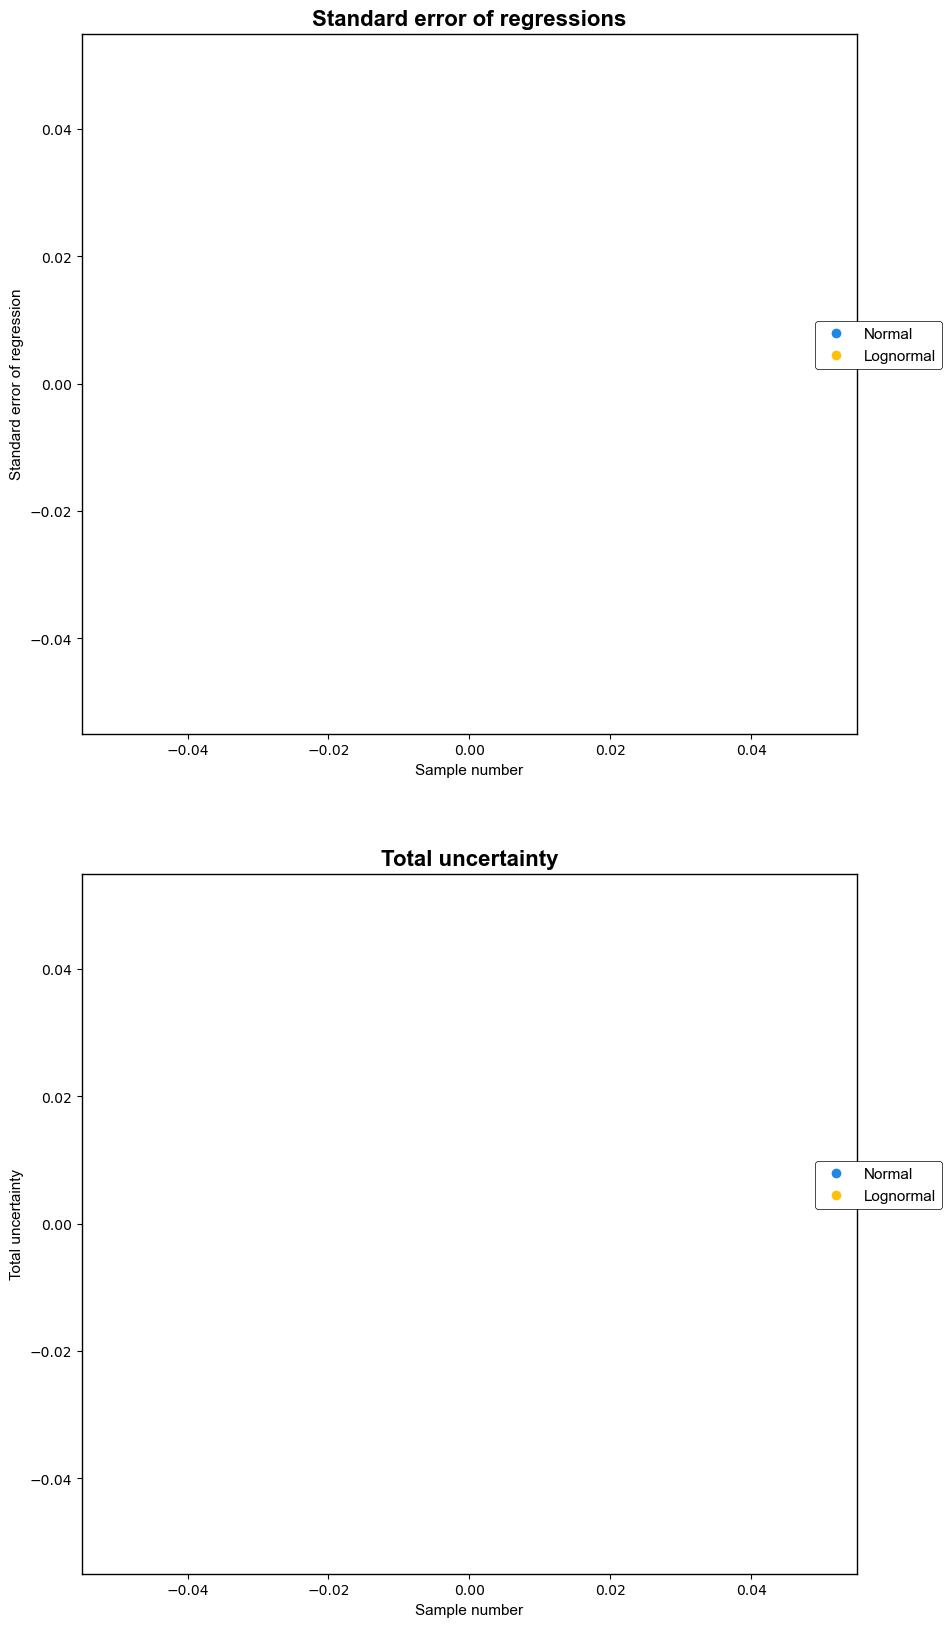

In [16]:
#making graphs based on highest and lowest SE


#create a list from 0 to max number of samples (-1) which will be used for x vals on plot below
x_values_SE_graph = list(range(0,len(starch_parameters_from_fittings_data_frame.index))) #len(starch_parameters_from_fittings_data_frame.index) = number of rows in dataframe
font = font_manager.FontProperties(family='Arial',
                                   style='normal', size=11)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,1,figsize=(10,20))

for spine in ['left','right','top','bottom']:
    ax[0].spines[spine].set_color('k')
ax[0].set_facecolor('white')
ax[0].set_ylabel("Standard error of regression", fontsize=11, fontname="Arial")
ax[0].xaxis.label.set_color('black')
ax[0].yaxis.label.set_color('black')
ax[0].tick_params(axis='both', which='major', colors='black')
ax[0].set_xlabel("Sample number", fontsize=11, fontname ="Arial")
ax[0].plot(x_values_SE_graph, starch_parameters_from_fittings_data_frame['Standard error of regression for the normal fitting'],
          linestyle="",marker="o", color = '#1e88e5ff', label='Normal')
ax[0].plot(x_values_SE_graph, starch_parameters_from_fittings_data_frame['Standard error of regression for the lognormal fitting'],
          linestyle="",marker="o", color = '#ffc107ff', label='Lognormal')
leg_00 = ax[0].legend(fontsize=11, bbox_to_anchor=(1.12, 0.6), ncol=1,facecolor='white', framealpha=1, prop=font)
leg_00.get_frame().set_edgecolor('k')
ax[0].set_title('Standard error of regressions', fontsize=16, fontname="Arial", weight="bold")


for spine in ['left','right','top','bottom']:
    ax[1].spines[spine].set_color('k')
ax[1].set_facecolor('white')
ax[1].set_ylabel("Total uncertainty", fontsize=11, fontname="Arial")
ax[1].xaxis.label.set_color('black')
ax[1].yaxis.label.set_color('black')
ax[1].tick_params(axis='both', which='major', colors='black')
ax[1].set_xlabel("Sample number", fontsize=11, fontname ="Arial")
ax[1].plot(x_values_SE_graph, starch_parameters_from_fittings_data_frame['Uncertainty for the normal fitting'],
          linestyle="",marker="o", color = '#1e88e5ff', label='Normal')
ax[1].plot(x_values_SE_graph, starch_parameters_from_fittings_data_frame['Uncertainty for the lognormal fitting'],
          linestyle="",marker="o", color = '#ffc107ff', label='Lognormal')

leg_00 = ax[1].legend(fontsize=11, bbox_to_anchor=(1.12, 0.6), ncol=1,facecolor='white', framealpha=1, prop=font)
leg_00.get_frame().set_edgecolor('k')
ax[1].set_title('Total uncertainty', fontsize=16, fontname="Arial", weight="bold")



plt.savefig('output/Plotted standard error of regressions and uncertainty.jpeg')